In [6]:
import xarray as xr
import numpy as np
import torch

# Load the dataset
ds = xr.open_dataset('/scratch/project_462000803/akhtar/climate_project/data/pangu_data/surface/surface_202301.nc')

# Extract the 'pm2p5' variable
pm2p5 = ds['pm2p5']

# Convert to a numpy array and reshape to (60, 1, 721, 1440)
pm2p5_array = pm2p5.values  # This gives you the array of shape (time, latitude, longitude)
pm2p5_array = np.expand_dims(pm2p5_array, axis=1)  # Add a singleton dimension (1) at index 1

# Check the shape of the result
print(pm2p5_array.shape)

(62, 1, 721, 1440)


In [7]:
pm2p5_tensor = torch.tensor(pm2p5_array, dtype=torch.float32)

In [ ]:
import matplotlib.pyplot as plt
import os

def visualize_surface(output, target, input, path):
    fig = plt.figure(figsize=(20, 2))

    # Ensure all inputs are NumPy arrays
    # Compute vmin and vmax across all relevant data for consistent color scaling
    output = output.detach().cpu().numpy() if not isinstance(output, np.ndarray) else output
    target = target.detach().cpu().numpy() if not isinstance(target, np.ndarray) else target
    input = input.detach().cpu().numpy() if not isinstance(input, np.ndarray) else input
    # Use percentiles for robust color scaling, which ignores extreme outliers
    vmin = np.percentile(input[var, :, :], 0)
    vmax = np.percentile(input[var, :, :], 80)

    ax1 = fig.add_subplot(151)
    plot1 = ax1.imshow(input[var, :, :], cmap="RdBu", vmin=vmin, vmax=vmax)
    plt.colorbar(plot1, ax=ax1, fraction=0.05, pad=0.05)
    ax1.title.set_text('input')

    # New subplot for the sliced region of 'input'
    ax2 = fig.add_subplot(152)
    plot2 = ax2.imshow(input[var, 179:388, 720:1026], cmap="RdBu", vmin=vmin, vmax=vmax)
    plt.colorbar(plot2, ax=ax2, fraction=0.05, pad=0.05)
    ax2.title.set_text('input_slice')

    ax3 = fig.add_subplot(153)
    plot3 = ax3.imshow(target[var, :, :], cmap="RdBu", vmin=vmin, vmax=vmax)
    plt.colorbar(plot3, ax=ax3, fraction=0.05, pad=0.05)
    ax3.title.set_text('gt')

    ax4 = fig.add_subplot(154)
    plot4 = ax4.imshow(output[var, :, :], cmap="RdBu", vmin=vmin, vmax=vmax)
    plt.colorbar(plot4, ax=ax4, fraction=0.05, pad=0.05)
    ax4.title.set_text('pred')

    ax5 = fig.add_subplot(155)
    plot5 = ax5.imshow(output[var, :, :] - target[var, :, :], cmap="RdBu")
    plt.colorbar(plot5, ax=ax5, fraction=0.05, pad=0.05)
    ax5.title.set_text('bias')

    plt.tight_layout()
    plt.savefig(fname=os.path.join(path, '{}_{}'.format(variables[var])))
    plt.close(fig)

In [ ]:
visualize_surface(pm2p5_array[0], pm2p5_array[0], pm2p5_array[0])

Mean: 1.0852864384958139e-08
Standard Deviation: 2.4637687445761003e-08
Min: 0.0
Max: 1.9189235899830237e-05
Median: 5.800481428508419e-09


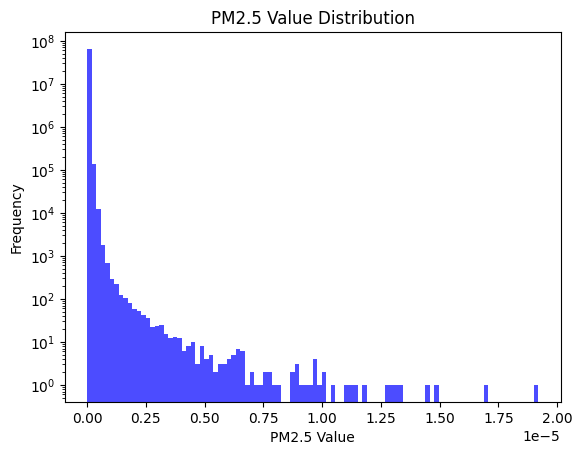

In [9]:
import torch

# Compute key statistics
mean = pm2p5_tensor.mean().item()
std = pm2p5_tensor.std().item()
min_val = pm2p5_tensor.min().item()
max_val = pm2p5_tensor.max().item()
median = pm2p5_tensor.median().item()

print(f"Mean: {mean}")
print(f"Standard Deviation: {std}")
print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median}")

# Histogram for visualization (if needed)
import matplotlib.pyplot as plt

plt.hist(pm2p5_tensor.flatten().cpu().numpy(), bins=100, color='blue', alpha=0.7)
plt.title("PM2.5 Value Distribution")
plt.xlabel("PM2.5 Value")
plt.ylabel("Frequency")
plt.yscale('log')  # Log scale for better visibility of low-frequency values
plt.show()